In [16]:
# This block is needed to block torchaudio (broken doesnt work)
# Instead for audio processing use soundfile 
import sys
for _mod in list(sys.modules):
    if 'torchcodec' in _mod:
        sys.modules[_mod] = None
for _mod in ['torchcodec', 'torchcodec.decoders', 'torchcodec._core']:
    sys.modules[_mod] = None
print('torchcodec blocked — soundfile will handle all audio I/O.')

torchcodec blocked — soundfile will handle all audio I/O.


In [17]:
import io   
import re
import time
import unicodedata
import torch
import soundfile as sf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline
from datasets import load_dataset, Audio
import jiwer
import librosa

In [18]:
models_english = [
    # ── Whisper family ──────────────────────────────────────────────────────
    'openai/whisper-tiny',           # 39M  params — baseline, already in original code
    'openai/whisper-base',           # 74M  params — already in original code
    'openai/whisper-small',          # 244M params — good speed/accuracy middle ground
    #'openai/whisper-medium',         # 769M params — strong multilingual
    #'openai/whisper-large-v3',       # 1.5B params — best OpenAI quality
    #'openai/whisper-large-v3-turbo', # 809M params — large-v3 pruned to 4 decoder layers;
                                     #               nearly as accurate, ~3x faster
    # ── Distil-Whisper family ───────────────────────────────────────────────
    'distil-whisper/distil-small.en',  # 166M — already in original code
    'distil-whisper/distil-medium.en', # 394M — good English-only balance
    #'distil-whisper/distil-large-v3',  # 756M — best distilled quality, multilingual
]

In [36]:
# We shall work with hindi and english datasets 
class ASRBenchmark:
    @staticmethod
    def normalise_english(text: str) -> str:
        text = text.lower().strip()
        text = re.sub(r'[^\w\s]', '', text)   # remove punctuation
        text = re.sub(r'\s+', ' ', text)
        return text
    
    # Initialise the benchmark with the chosen language and dataset size
    def __init__(self, data_range = 100):
        self.language = 'english'
        self.data_range = data_range
        self.models = models_english
        self.dataset = load_dataset("hf-internal-testing/librispeech_asr_dummy", "clean", split="validation")
        self.dataset = self.dataset.select(range(min(self.data_range, len(self.dataset))))
        self.dataset = self.dataset.cast_column('audio', Audio(decode=False))  # ← missing
        self.model_configs = None
        self.normalise_text = self.normalise_english
        self.TEXT_COL = 'text'

    # Run the benchmark across all models and compute WERs
    def run(self):
        self.results = []
        self.decoded = {}
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        TARGET_SR = 16_000

        for model_id in self.models:
            name = model_id.split('/')[-1]
            print(f"Evaluating {name}...")

            extra = self.model_configs.get(model_id, {}) if self.model_configs else {}
            asr = pipeline('automatic-speech-recognition', model=model_id, device=device, **extra)

            audio_duration = 0
            inference_time = 0
            preds = []
            refs = []

            for sample in self.dataset:
                audio_bytes = sample['audio']['bytes']
                audio_array, sr = sf.read(io.BytesIO(audio_bytes), dtype='float32')

                if audio_array.ndim > 1:
                    audio_array = audio_array.mean(axis=1)  # Convert to mono by averaging channels

                if sr != TARGET_SR:
                    audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=TARGET_SR)
                    sr = TARGET_SR

                ref = self.normalise_text(sample[self.TEXT_COL])
                audio_duration += len(audio_array) / sr

                start_time = time.time()
                result = asr({'array': audio_array, 'sampling_rate': sr})
                inference_time += time.time() - start_time

                pred = self.normalise_text(result['text'])
                preds.append(pred)
                refs.append(ref)

            word_measures = jiwer.process_words(refs, preds)
            char_measures = jiwer.process_characters(refs, preds)
            wer = word_measures.wer
            cer = char_measures.cer
            ser = sum(1 for r, p in zip(refs, preds) if r.strip() != p.strip()) / len(refs)

            rtf = inference_time / audio_duration if audio_duration > 0 else np.nan
            self.results.append({'model': name, 'WER': wer, 'CER': cer, 'SER': ser, 'RTF': rtf})
            self.decoded[name] = list(zip(refs, preds))

            print(f"  WER: {wer:.4f}, CER: {cer:.4f}, SER: {ser:.4f}, RTF: {rtf:.4f}")
            print(f"  Total audio duration: {audio_duration:.2f}s, Total inference time: {inference_time:.2f}s")

    def sample_predictions(self, n=5):
        for model_name in self.decoded:
            print(f"== Sample Predictions for {model_name} ==")
            samples = self.decoded[model_name][:n]
            for ref, pred in samples:
                print(f"  Reference: {ref}")
                print(f"  Prediction: {pred}")
                print("  " + "-"*50)

    @staticmethod
    def convert_results_to_dataframe(results):
        return pd.DataFrame(results).set_index('model')
    
    @staticmethod
    def plot_results(df):
        metrics = ['WER', 'CER', 'SER', 'RTF']
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle('ASR Model Benchmarking Results', fontsize=16)

        for i, metric in enumerate(metrics):
            ax = axes[i//2, i%2]
            df[metric].plot(kind='bar', ax=ax, color='skyblue')
            ax.set_title(metric)
            ax.set_ylabel(metric)
            ax.set_xlabel('Model')
            ax.set_xticklabels(df.index, rotation=45, ha='right')
            ax.grid(axis='y')   

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

In [20]:
benchmark = ASRBenchmark(data_range=100)
benchmark.run()

Evaluating whisper-tiny...


Loading weights: 100%|██████████| 167/167 [00:00<00:00, 4444.13it/s]
Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLog

  WER: 0.1096, CER: 0.0511, SER: 0.7123, RTF: 0.3326
  Total audio duration: 481.03s, Total inference time: 159.99s
Evaluating whisper-base...


Loading weights: 100%|██████████| 245/245 [00:00<00:00, 1184.88it/s]


  WER: 0.0930, CER: 0.0431, SER: 0.6986, RTF: 0.6540
  Total audio duration: 481.03s, Total inference time: 314.62s
Evaluating whisper-small...


...

  WER: 0.0783, CER: 0.0347, SER: 0.6027, RTF: 1.6333
  Total audio duration: 481.03s, Total inference time: 785.69s
Evaluating distil-small.en...


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 2144.97it/s]


  WER: 0.0722, CER: 0.0300, SER: 0.6301, RTF: 3.7621
  Total audio duration: 481.03s, Total inference time: 1809.69s
Evaluating distil-medium.en...


c:\Users\Tanay\Documents\EE679\Project\ASR\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Tanay\.cache\huggingface\hub\models--distil-whisper--distil-medium.en. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 419/419 [00:00<00:00, 1166.86it/s]


  WER: 0.0696, CER: 0.0341, SER: 0.5205, RTF: 1.7099
  Total audio duration: 481.03s, Total inference time: 822.54s


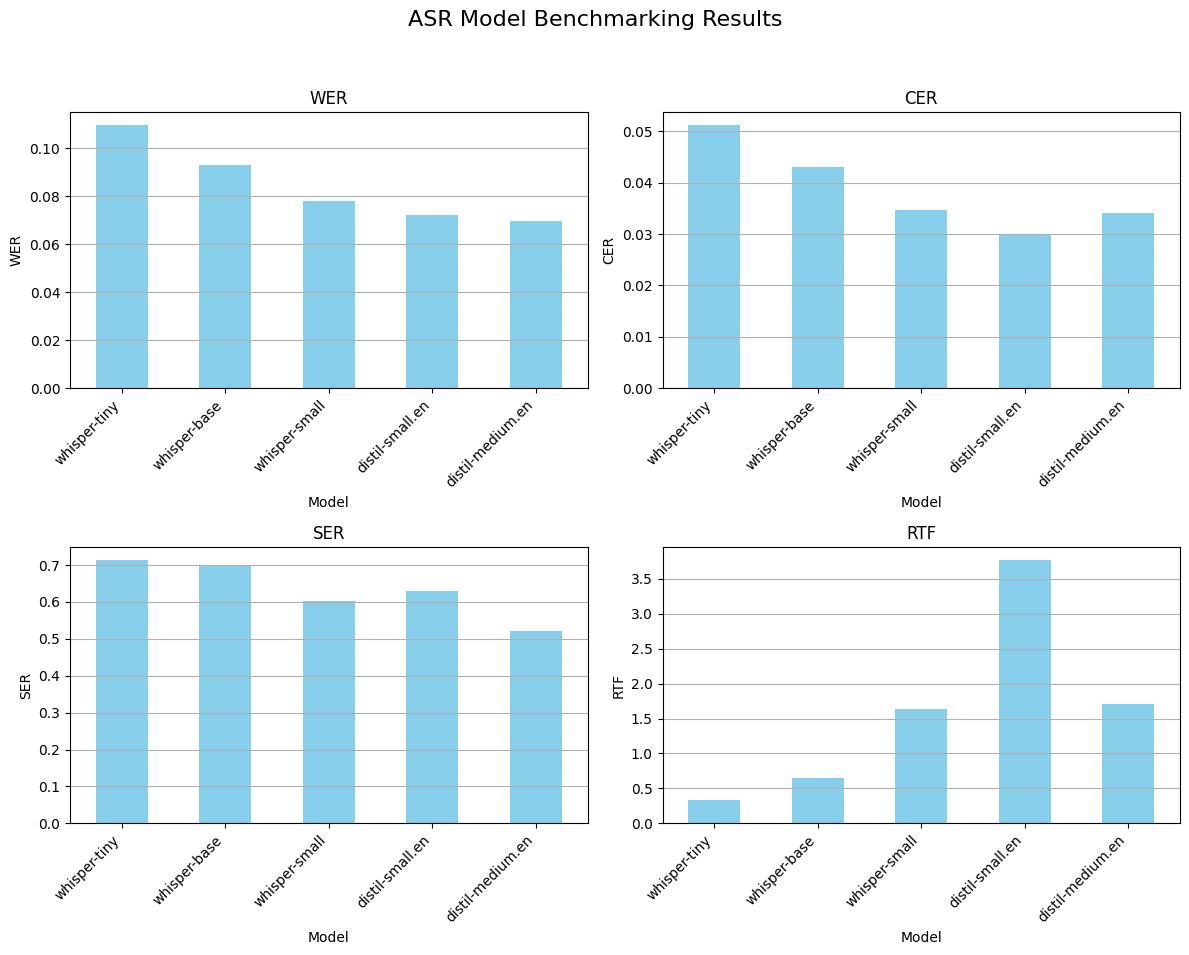

In [35]:
benchmark_df = benchmark.convert_results_to_dataframe(benchmark.results)
benchmark.plot_results(benchmark_df)